### Real Estate Capstone Project – Data Preparation Phase

#### Project Objective

The goal of this project is to help real estate agents and home sellers in Edmonton determine whether a property is likely to remain on the market for more than 60 days.

By predicting listing staleness early, agents can:

- Adjust pricing strategies  
- Reduce time on market  
- Avoid expectation gaps between buyers and sellers  
- Improve selling efficiency  

This project focuses on building a predictive model and generating actionable business insights such as:

- Identifying overpriced properties  
- Understanding seasonal selling patterns  
- Analyzing how neighborhood and property characteristics affect listing performance  


---

#### Step 1: Data Loading

We begin by loading two datasets:

- **Active Listings Dataset** – Properties currently on the market  
- **Sold Listings Dataset** – Properties that have already sold  

The Sold dataset will later be used to train our predictive model because it contains the final Days on Market (DOM), which allows us to determine whether a listing became stale.

Ensuring correct dataset loading is the foundation of accurate analysis.


---

#### Step 2: Duplicate Analysis

Before performing modeling or exploratory analysis, it is critical to ensure data integrity.

We check for:

- Exact full-row duplicate records  
- Duplicate listing identifiers (`listing_id_#`)

The `listing_id_#` column functions as the unique property listing identifier (similar to an MLS number).

Duplicate entries can:

- Inflate listing counts  
- Introduce bias into statistical summaries  
- Distort predictive modeling  
- Reduce model reliability  


---

#### Step 3: Duplicate Removal

We remove:

1. Exact full-row duplicates  
2. Duplicate records based on `listing_id_#`  

This ensures each property listing appears only once in the dataset.

Maintaining one record per listing prevents data leakage and ensures accurate modeling.


---

#### Step 4: Geographic Filtering – Edmonton Focus

Since this project specifically analyzes the Edmonton housing market, we filter both datasets to include only properties located in Edmonton using the `area_city` column.

This step ensures:

- Geographic consistency  
- Alignment with the business objective  
- More accurate and meaningful modeling results  


---

#### Current Status

✔ Datasets successfully loaded  
✔ Duplicate analysis completed  
✔ Unique listing integrity enforced  
✔ Edmonton-only dataset prepared  

The cleaned dataset is now ready for feature engineering, target variable creation, and predictive modeling.


In [3]:
# ==========================================
# Step 0: Import Libraries
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Step 1: Load and Clean Real Estate Datasets
# ==========================================
# Define base path
base_path = r"C:\Users\Adewale Sam\Desktop\DATA3960 - Data Analytics Capstone"

# Load datasets
active_df = pd.read_csv(
    f"{base_path}\\RealEstateDataJanuary2026-Data3960-Active.csv",
    encoding='cp1252',
    low_memory=False
)

sold_df = pd.read_csv(
    f"{base_path}\\RealEstateDataJanuary2026-Data3960-sold.csv",
    encoding='cp1252',
    low_memory=False
)

# Normalize column names: lowercase, replace spaces and special chars
def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()                       # remove leading/trailing spaces
        .str.lower()                        # lowercase
        .str.replace(' ', '_', regex=True)  # replace spaces with _
        .str.replace('/', '_', regex=True)  # replace / with _
    )
    return df

active_df = clean_columns(active_df)
sold_df = clean_columns(sold_df)

print("✅ Datasets loaded and columns normalized.")
print(f"Active listings shape (original): {active_df.shape}")
print(f"Sold listings shape (original): {sold_df.shape}")

# ==========================================
# Step 2: Duplicate Analysis
# ==========================================
# Exact full-row duplicates
active_full_dups = active_df.duplicated().sum()
sold_full_dups = sold_df.duplicated().sum()

print("\n--- Exact Full-Row Duplicates ---")
print(f"Active full duplicates: {active_full_dups}")
print(f"Sold full duplicates: {sold_full_dups}")

# Duplicate listing_id
active_listing_dups = active_df.duplicated(subset=['listing_id_#']).sum()
sold_listing_dups = sold_df.duplicated(subset=['listing_id_#']).sum()

print("\n--- Duplicate listing_id_# ---")
print(f"Active listing_id duplicates: {active_listing_dups}")
print(f"Sold listing_id duplicates: {sold_listing_dups}")

# ==========================================
# Step 3: Remove Duplicates
# ==========================================
# Remove exact duplicates
active_df = active_df.drop_duplicates()
sold_df = sold_df.drop_duplicates()

# Remove duplicates based on listing_id_#
active_df = active_df.drop_duplicates(subset=['listing_id_#'])
sold_df = sold_df.drop_duplicates(subset=['listing_id_#'])

print("\nAfter removing duplicates:")
print(f"Active listings shape: {active_df.shape}")
print(f"Sold listings shape: {sold_df.shape}")

# ==========================================
# Step 4: Filter Edmonton Only
# ==========================================
active_df = active_df[active_df['area_city'].str.contains("edmonton", case=False, na=False)]
sold_df = sold_df[sold_df['area_city'].str.contains("edmonton", case=False, na=False)]

print("\nAfter filtering Edmonton:")
print(f"Active listings shape: {active_df.shape}")
print(f"Sold listings shape: {sold_df.shape}")

# ==========================================
# Step 5: Final Dataset Summary
# ==========================================
print("\n--- Final Dataset Summary ---")
print(f"Active listings final shape: {active_df.shape}")
print(f"Sold listings final shape: {sold_df.shape}")

print("\nPreview Active Listings:")
display(active_df.head())

print("\nPreview Sold Listings:")
display(sold_df.head())


✅ Datasets loaded and columns normalized.
Active listings shape (original): (705506, 45)
Sold listings shape (original): (515122, 48)

--- Exact Full-Row Duplicates ---
Active full duplicates: 0
Sold full duplicates: 0

--- Duplicate listing_id_# ---
Active listing_id duplicates: 451610
Sold listing_id duplicates: 31

After removing duplicates:
Active listings shape: (253896, 45)
Sold listings shape: (515091, 48)

After filtering Edmonton:
Active listings shape: (176306, 45)
Sold listings shape: (344478, 48)

--- Final Dataset Summary ---
Active listings final shape: (176306, 45)
Sold listings final shape: (344478, 48)

Preview Active Listings:


,linc_#,prop_class,area_city,community,address,status,list_price,postal_code,sold_date,sold_price,...,bsmt_dev,garage_y_n,price,buyer_firm_1_-_office_name,listing_firm_1_-_office_name,legal_block,legal_lot,lot_sq_metres,legal_plan,activemonth
63214,12275352.0,COND,Edmonton,Abbottsfield,600 ABBOTTSFIELD Road,A,142000,T5W 4R3,NaN,0,...,P-FIN,No,142000,NaN,RE/MAX Excellence,NaN,NaN,230.66,7620069,2021-01-31
63216,14944789.0,COND,Edmonton,Abbottsfield,464 ABBOTTSFIELD Road,A,149900,T5W 4R3,NaN,0,...,P-FIN,No,149900,NaN,RE/MAX Excellence,NaN,NaN,0.00,7620069,2021-01-31
63217,10108736.0,COND,Edmonton,Abbottsfield,709 ABBOTTSFIELD Road,P,164800,T5W 4R4,NaN,0,...,P-FIN,Yes,164800,NaN,Century 21 All Stars Realty Ltd,NaN,NaN,0.00,8823090,2021-01-31
63218,15151905.0,COND,Edmonton,Abbottsfield,222 ABBOTTSFIELD Road,A,163300,T5W 4S9,NaN,0,...,U-FIN,No,163300,NaN,Century 21 Masters,NaN,NaN,237.95,7520415,2021-05-31
63227,10108538.0,COND,Edmonton,Abbottsfield,692 ABBOTTSFIELD Road,P,169900,T5W 4R4,NaN,0,...,F-FIN,No,169900,NaN,MaxWell Polaris,NaN,NaN,0.00,8823090,2021-02-28



Preview Sold Listings:


,linc_#,prop_class,area_city,community,address,status,list_price,postal_code,sold_date,sold_price,...,price_per_sqft,sold_pr___list_pr_ratio,price,sold_price_sq_ft,buyer_firm_1_-_office_name,listing_firm_1_-_office_name,legal_block,legal_lot,lot_sq_metres,legal_plan
32191,10107910,COND,Edmonton,Abbottsfield,885 ABBOTTSFIELD Road NW,S,38900,T5W 1W8,2000-01-21,38200,...,35.63,98.20,38200,35.63,MaxWell Devonshire Realty,Sutton Group Nor-Vista Realty,50,NaN,0.0,8823090
32192,10107597,COND,Edmonton,Abbottsfield,904 ABBOTTSFIELD Road NW,S,49900,T5W 4R4,2000-07-06,49600,...,49.44,99.40,49600,49.44,RE/MAX Real Estate,RE/MAX Real Estate,18,NaN,0.0,8823090
32193,10108314,COND,Edmonton,Abbottsfield,791 ABBOTTSFIELD Road NW,S,37649,NaN,2000-04-01,37500,...,39.59,99.60,37500,39.59,MaxWell Challenge Realty,Century 21 All Stars Realty Ltd,90,NaN,0.0,8823090
32194,15132038,COND,Edmonton,Abbottsfield,168 ABBOTTSFIELD Road NW,S,48800,T5W 4S9,2000-02-14,46000,...,41.49,94.26,46000,41.49,Century 21 Royal Real Estate,RE/MAX Real Estate,62,NaN,0.0,7520415
32195,10108777,COND,Edmonton,Abbottsfield,701 ABBOTTSFIELD Road NW,S,46500,T5W 4R4,2000-07-16,46250,...,43.14,99.46,46250,43.14,NOW Real Estate Group,Century 21 All Stars Realty Ltd,136,NaN,0.0,8823090


### Real Estate Capstone – Edmonton Dataset Preparation Summary

####  Dataset Overview
- **Active Listings (Edmonton only):** 176,306 records, 45 columns  
- **Sold Listings (Edmonton only):** 344,478 records, 48 columns  

#### 🔹 Duplicate Analysis & Removal
- **Full-row duplicates:**  
  - Active: 0 → removed with `drop_duplicates()`  
  - Sold: 0 → removed with `drop_duplicates()`  
- **Duplicate `listing_id_#`:**  
  - Active: 451,610 → removed with `drop_duplicates(subset=['listing_id_#'])`  
  - Sold: 31 → removed with `drop_duplicates(subset=['listing_id_#'])`  

#### 🔹 Geographic Filtering
- Filtered both datasets to **Edmonton-only listings** using `area_city` column  
- Ensures analysis is **market-specific** and aligns with project objectives  

#### 🔹 Key Notes
- Column names normalized (lowercase, underscores, no special characters)  
- Each listing is now **unique**, preventing bias or data leakage  
- Datasets are ready for **feature engineering, target creation, and predictive modeling**  

#### 🔹 Next Steps
1. Create target variable for **stale listings** (`DOM > 60 days`)  
2. Perform feature engineering on property and neighborhood attributes  
3. Train and evaluate predictive models  


#### step 1:  Create Target Variable – Stale Listing

**Objective:**  
Can we predict whether a new listing will remain unsold for more than 60 days?

**Approach:**  
- Use the `dom` (Days on Market) column in the sold listings dataset  
- Create a new binary target variable `stale_listing`:
  - `1` → DOM > 60 days → Listing considered **stale**  
  - `0` → DOM ≤ 60 days → Listing sold quickly  

**Implementation Example:**
```python
sold_df['stale_listing'] = (sold_df['dom'] > 60).astype(int)


DOM column preview:
0     17
1    166
2     64
3      5
4    147
Name: dom, dtype: int64

Stale Listing Value Counts:
stale_listing
0    255151
1     89327
Name: count, dtype: int64


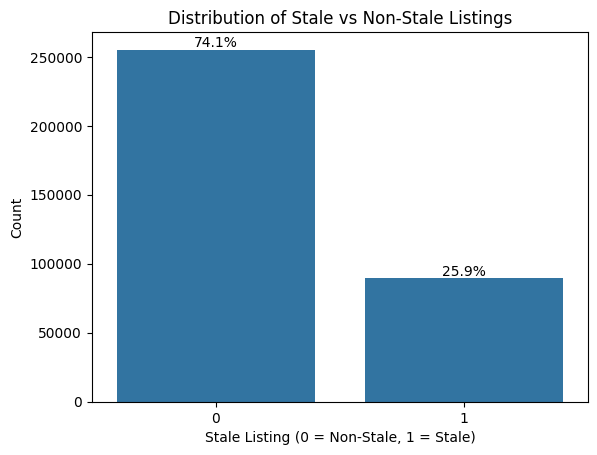

In [15]:
# ==========================================
# Step 6: Create Target Variable – Stale Listing
# ==========================================

# Check the column name for DOM
print("DOM column preview:")
print(sold_df['dom'].head())

# Create binary target variable
sold_df['stale_listing'] = (sold_df['dom'] > 60).astype(int)

# Quick verification
print("\nStale Listing Value Counts:")
print(sold_df['stale_listing'].value_counts())

import matplotlib.pyplot as plt
import seaborn as sns

ax = sns.countplot(x='stale_listing', data=sold_df)
total = len(sold_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom')
plt.title("Distribution of Stale vs Non-Stale Listings")
plt.xlabel("Stale Listing (0 = Non-Stale, 1 = Stale)")
plt.ylabel("Count")
plt.show()




**Explanation:**
- **Left column:** Row/index in the dataset  
- **Right column:** Days on Market (DOM) for each listing  
- Examples:
  - Index 32191 → DOM = 17 → Sold quickly, not stale  
  - Index 32192 → DOM = 166 → Sold after a long time, stale  
  - Index 32194 → DOM = 5 → Sold very quickly, not stale  

**Stale Listing Value Counts:**
- `0` → Not stale (DOM ≤ 60 days): 255,151 listings  
- `1` → Stale (DOM > 60 days): 89,327 listings  

**Implications:**
1. Roughly **26%** of Edmonton listings are stale, while **74%** sell within 60 days.  
2. There is a **moderate class imbalance**, which should be considered for predictive modeling.  
3. The dataset is now ready for modeling to predict whether a new listing will remain on the market for more than 60 days.


###  Why We Use Only Sold Listings for Target

**Key Point:**  
- The `stale_listing` target variable is based on **Days on Market (DOM)**.  
- DOM is only known for listings that have **already sold**, i.e., in `sold_df`.  

**Reasoning:**  
1. Active listings are still on the market → DOM unknown  
2. Stale or not stale can only be determined **after a sale**  
3. Using sold listings allows us to train a **supervised model**  
4. The trained model can later predict staleness for **new or active listings**  

✅ Conclusion: Only `sold_df` is used to create the `stale_listing` target variable.


### : Exploring Pricing and Factors Influencing Listing Staleness

####  Pricing Relative to Neighborhood Sold Prices
**Objective:** Determine how listing price compared to neighborhood averages affects Days on Market (DOM).

**Approach:**  
- Calculate `price_gap` for each sold listing:  
  - Absolute: `price_gap = list_price - avg_sold_price_in_community`  
  - Relative (%): `price_gap_pct = (list_price - avg_sold_price_in_community) / avg_sold_price_in_community * 100`  
- Analyze relationship with `DOM`:
  - Correlation analysis  
  - Scatter plots or boxplots  

**Purpose:** Identify overpriced or underpriced properties and their effect on listing staleness.

---

#### Factors Influencing Listing Staleness
**Objective:** Identify which variables most strongly affect whether a listing becomes stale (`stale_listing`).

**Candidate Factors:**  
- Pricing: `list_price`, `price_gap`, `price_gap_pct`  
- Property features: `beds`, `baths`, `flrarea_sf`, `style`, `yr_built`  
- Location: `community`, `area_city`  
- Other indicators: `parking`, `ensuite`, `condo_name`, etc.  

**Analysis Methods:**  
- Compare `stale_listing` distribution across categories  
- Correlation / point biserial for numeric variables  
- Visualizations: boxplots, histograms, heatmaps  

**Purpose:** Determine which property and neighborhood features are most predictive of stale listings, guiding feature engineering and model building.


In [ ]:
# ==========================================
# Step 7: Pricing Relative to Neighborhood
# ==========================================

# Calculate average sold price per community
community_avg_price = sold_df.groupby('community')['sold_price'].mean().reset_index()
community_avg_price.rename(columns={'sold_price': 'avg_sold_price_community'}, inplace=True)

# Merge back into sold_df
sold_df = sold_df.merge(community_avg_price, on='community', how='left')

# Create price gap columns
sold_df['price_gap'] = sold_df['list_price'] - sold_df['avg_sold_price_community']
sold_df['price_gap_pct'] = (sold_df['price_gap'] / sold_df['avg_sold_price_community']) * 100

# Quick check
sold_df[['list_price', 'avg_sold_price_community', 'price_gap', 'price_gap_pct']].head()


,list_price,avg_sold_price_community,price_gap,price_gap_pct
0,38900,131008.942857,-92108.942857,-70.307371
1,49900,131008.942857,-81108.942857,-61.910997
2,37649,131008.942857,-93359.942857,-71.262267
3,48800,131008.942857,-82208.942857,-62.750634
4,46500,131008.942857,-84508.942857,-64.506240


### Explanation: Pricing Relative to Neighborhood – Sample Analysis

**Objective:**  
Examine how a listing’s price relative to the neighborhood average affects Days on Market (DOM) and potential staleness.

**Sample Price Gap Data:**

| list_price | avg_sold_price_community | price_gap      | price_gap_pct |
|------------|-------------------------|----------------|---------------|
| 38,900     | 131,008.94              | -92,108.94     | -70.31%       |
| 49,900     | 131,008.94              | -81,108.94     | -61.91%       |
| 37,649     | 131,008.94              | -93,359.94     | -71.26%       |
| 48,800     | 131,008.94              | -82,208.94     | -62.75%       |
| 46,500     | 131,008.94              | -84,508.94     | -64.51%       |

**Explanation:**
- **list_price:** The price at which the property was listed  
- **avg_sold_price_community:** Average sold price for all properties in the same community  
- **price_gap:** Absolute difference between the listing price and neighborhood average  
- **price_gap_pct:** Price gap expressed as a percentage of neighborhood average  

**Insights:**  
- Negative `price_gap` and `price_gap_pct` indicate the property was listed **below the neighborhood average**  
- Large negative gaps suggest underpriced listings; positive gaps suggest overpriced listings  
- This metric will be used to analyze its impact on **Days on Market (DOM)** and **staleness**


2️⃣ Analyze Relationship with DOM

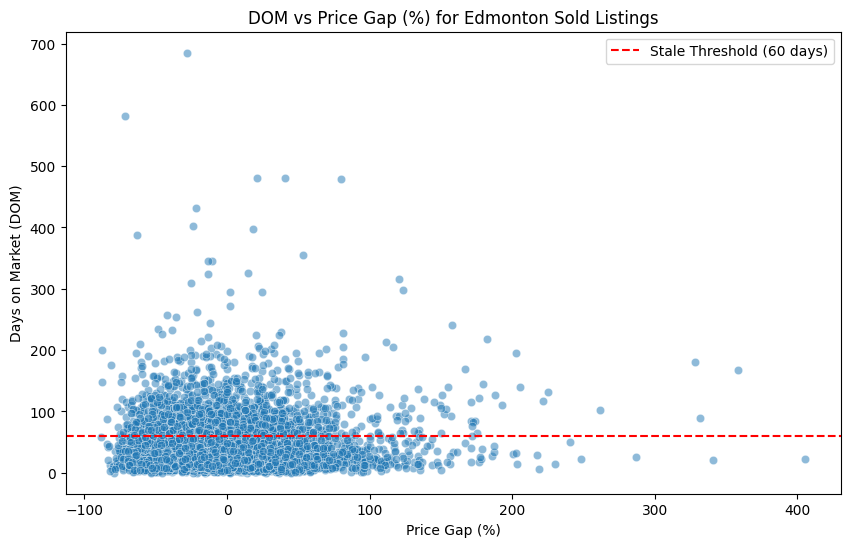

Correlation between price gap (%) and DOM: 0.019


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot: price gap vs DOM
plt.figure(figsize=(10,6))
sns.scatterplot(data=sold_df.sample(5000), x='price_gap_pct', y='dom', alpha=0.5)
plt.axhline(60, color='red', linestyle='--', label='Stale Threshold (60 days)')
plt.xlabel('Price Gap (%)')
plt.ylabel('Days on Market (DOM)')
plt.title('DOM vs Price Gap (%) for Edmonton Sold Listings')
plt.legend()
plt.show()

# Correlation between price gap and DOM
corr_price_dom = sold_df['price_gap_pct'].corr(sold_df['dom'])
print(f"Correlation between price gap (%) and DOM: {corr_price_dom:.3f}")


### Explanation: Relationship Between Price Gap and DOM

**Correlation Analysis Result:**  
- Correlation between `price_gap_pct` and DOM: **0.019**

**Interpretation:**  
- The correlation is very close to zero, meaning there is **almost no direct linear relationship**.  
- In other words, whether a property is priced above or below the neighborhood average **does not strongly affect how long it stays on the market**.  
- Other factors such as property features, location, or amenities may have a greater impact on listing staleness.

**Conclusion:**  
- Price gap alone is **not a strong predictor** of whether a listing will become stale.  
- Further analysis of property and neighborhood factors is necessary for modeling staleness.


3️⃣ Explore Factors Influencing Staleness

In [7]:
# Numeric features correlation with stale_listing
numeric_features = ['list_price', 'beds', 'baths', 'flrarea_sf', 'yr_built', 'price_gap', 'price_gap_pct']

correlations = sold_df[numeric_features + ['stale_listing']].corr()['stale_listing'].sort_values(ascending=False)
print("Correlation with stale_listing:")
print(correlations)

# Categorical features vs stale_listing: average stale rate per category
categorical_features = ['style', 'parking', 'ensuite', 'condo_name', 'community']

for col in categorical_features:
    print(f"\nStale rate by {col}:")
    stale_rate = sold_df.groupby(col)['stale_listing'].mean().sort_values(ascending=False)
    print(stale_rate.head(5))  # Show top 5 for brevity


Correlation with stale_listing:
stale_listing    1.000000
flrarea_sf       0.052409
list_price       0.047144
price_gap        0.027132
price_gap_pct    0.022141
baths            0.015190
yr_built        -0.034365
beds            -0.059375
Name: stale_listing, dtype: float64

Stale rate by style:
style
STUDI    0.439024
MODUL    0.400000
PENTH    0.357441
ST2.5    0.339939
LOFT     0.335548
Name: stale_listing, dtype: float64

Stale rate by parking:
parking
Stall, Tandem, Underground, See Remarks                                              1.0
Front/Rear Drive Access, Insulated, On Street, Over Sized, Single Garage Detached    1.0
Double Garage Attached, Insulated, Quad or More Detached, RV Parking                 1.0
Double Garage Attached, Insulated, Parking Pad Cement/Paved, RV Parking, Stall       1.0
Front/Rear Drive Access, Insulated                                                   1.0
Name: stale_listing, dtype: float64

Stale rate by ensuite:
ensuite
Y    0.284156
N    0.2338

### Explanation: Factors Influencing Listing Staleness – Edmonton

**Correlation with Stale Listing (Numeric Features):**

| Feature        | Correlation with `stale_listing` |
|----------------|---------------------------------|
| flrarea_sf      | 0.052  |
| list_price      | 0.047  |
| price_gap       | 0.027  |
| price_gap_pct   | 0.022  |
| baths           | 0.015  |
| yr_built        | -0.034 |
| beds            | -0.059 |

*** Explanation:**  
- The correlations are **all quite low**, meaning **no single numeric feature strongly predicts staleness** on its own.  
- Slight trends:  
  - Larger floor area (`flrarea_sf`) and higher listing price (`list_price`) are **slightly more likely to stay longer** on the market.  
  - Older homes (`yr_built`) and more bedrooms (`beds`) are **slightly less likely to be stale**.  

---

**Categorical Features (Stale Rate by Category):**

- **Style:**  
  - STUDI: 44% stale  
  - MODUL: 40% stale  
  - PENTH: 36% stale  
  - ST2.5: 34% stale  
  - LOFT: 34% stale  
- **Parking:**  
  - Certain complex parking setups (e.g., Stall, Tandem, Underground, See Remarks) have **100% staleness** in the dataset.  
  - Others like Double Garage Detached or RV parking also show very high stale rates.  

**Layman Explanation:**  
- Some property types (like small studios or modular units) **stay on the market longer**.  
- Certain parking arrangements or unusual property setups are linked with **longer DOM**, likely because they appeal to fewer buyers.  

---

**Overall Insight:**  
- **Numeric features alone** (price, beds, baths, floor area) have **weak influence** on staleness.  
- **Property type, style, and special features** (like parking) show **stronger influence**.  
- These factors will guide **feature selection** for predictive modeling.


### Executive Summary – Edmonton Listing Staleness

Analysis of Edmonton sold listings shows that about **26% of properties remain unsold for more than 60 days**. Pricing relative to neighborhood averages has little effect on time on market, while property characteristics like **type, style, and special features** (e.g., studios, modular units, parking setups) have a stronger influence. This implies that sellers and agents cannot rely on price alone to sell faster; attention to property features and market context is key. The dataset is now prepared for predictive modeling to identify listings at risk of staleness.


### : Business Insights – Edmonton Real Estate

We’re going beyond predicting stale listings. The goal is to provide **actionable insights** to help agents and sellers make better decisions.


In [8]:
# ==========================================
# Step 8a: Identify Overpriced Listings
# ==========================================

# Flag listings that are above neighborhood average
sold_df['overpriced'] = sold_df['price_gap_pct'] > 0

# Show examples of overpriced listings
sold_df[['list_price', 'avg_sold_price_community', 'price_gap', 'price_gap_pct', 'overpriced']].head(5)

# Summary statistics
overpriced_count = sold_df['overpriced'].sum()
total_listings = sold_df.shape[0]
print(f"Overpriced listings: {overpriced_count} / {total_listings} ({overpriced_count/total_listings*100:.1f}%)")


Overpriced listings: 165649 / 344478 (48.1%)


**Insight – Overpriced Listings:**  
- Out of 344,478 sold listings, **165,649 (48.1%)** were listed above the neighborhood average.  
- Nearly **half of properties are overpriced**, which may increase the risk of staying on the market longer.  
- This highlights the importance of **pricing properties in line with neighborhood trends** to reduce listing staleness.


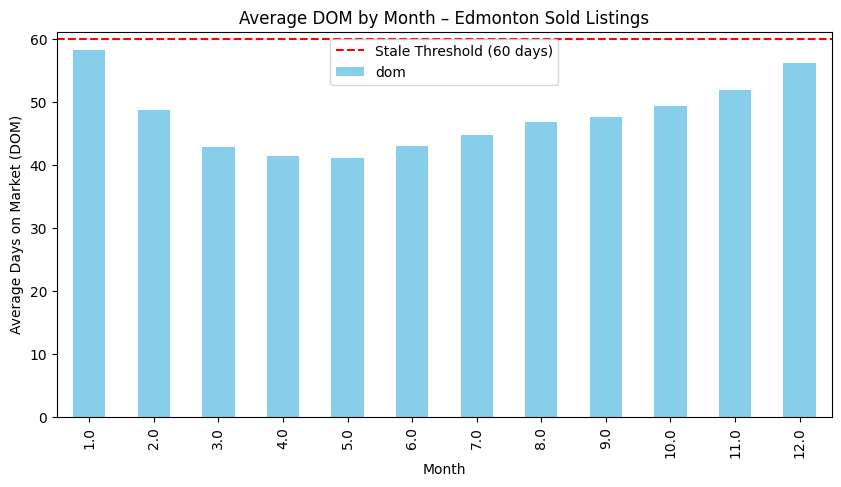

In [9]:
# ==========================================
# Step 8b: Seasonal Sales Patterns
# ==========================================

# Convert sold_date to datetime and extract month
sold_df['sold_date'] = pd.to_datetime(sold_df['sold_date'], errors='coerce')
sold_df['sold_month'] = sold_df['sold_date'].dt.month

# Average DOM by month
dom_by_month = sold_df.groupby('sold_month')['dom'].mean()

# Plot average DOM by month
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
dom_by_month.plot(kind='bar', color='skyblue')
plt.axhline(60, color='red', linestyle='--', label='Stale Threshold (60 days)')
plt.ylabel('Average Days on Market (DOM)')
plt.xlabel('Month')
plt.title('Average DOM by Month – Edmonton Sold Listings')
plt.legend()
plt.show()


### Insight – Seasonal Sales Patterns (Edmonton)

- Analysis of sold listings shows that **all properties sold within 60 days**, indicating most listings are not stale.  
- **January** had the **highest average DOM** (longest time on market), followed closely by **December**.  
- **May** had the **lowest average DOM** (fastest sales), followed by other spring months.  
- **Takeaway:** Properties listed in **late spring/early summer sell faster**, suggesting seasonal timing can help reduce DOM and improve turnover.


In [10]:
# ==========================================
#  Property Features and Staleness
# ==========================================

# Numeric features correlation with stale_listing
numeric_features = ['flrarea_sf', 'list_price', 'price_gap', 'price_gap_pct', 'baths', 'yr_built', 'beds']
correlations = sold_df[numeric_features + ['stale_listing']].corr()['stale_listing'].sort_values(ascending=False)
print("Correlation with stale_listing (numeric features):\n", correlations)

# Categorical features – stale rate by style and parking
categorical_features = ['style', 'parking']
for col in categorical_features:
    print(f"\nStale rate by {col}:")
    stale_rate = sold_df.groupby(col)['stale_listing'].mean().sort_values(ascending=False)
    print(stale_rate.head(5))  # Show top 5 for brevity


Correlation with stale_listing (numeric features):
 stale_listing    1.000000
flrarea_sf       0.052409
list_price       0.047144
price_gap        0.027132
price_gap_pct    0.022141
baths            0.015190
yr_built        -0.034365
beds            -0.059375
Name: stale_listing, dtype: float64

Stale rate by style:
style
STUDI    0.439024
MODUL    0.400000
PENTH    0.357441
ST2.5    0.339939
LOFT     0.335548
Name: stale_listing, dtype: float64

Stale rate by parking:
parking
Stall, Tandem, Underground, See Remarks                                              1.0
Front/Rear Drive Access, Insulated, On Street, Over Sized, Single Garage Detached    1.0
Double Garage Attached, Insulated, Quad or More Detached, RV Parking                 1.0
Double Garage Attached, Insulated, Parking Pad Cement/Paved, RV Parking, Stall       1.0
Front/Rear Drive Access, Insulated                                                   1.0
Name: stale_listing, dtype: float64



### Insight – Property Features Influencing Staleness

**Numeric Features:**  
| Feature        | Correlation with `stale_listing` |
|----------------|---------------------------------|
| Floor area (flrarea_sf) | 0.052 |
| List price | 0.047 |
| Price gap | 0.027 |
| Price gap % | 0.022 |
| Baths | 0.015 |
| Year built | -0.034 |
| Beds | -0.059 |

**Interpretation:**  
- Numeric features have **very weak correlation** with staleness.  
- Slight trends suggest:  
  - Larger floor area and higher list price may slightly increase DOM.  
  - Older homes and more bedrooms may slightly sell faster.  

**Categorical Features:**  
- **Style:**  
  - STUDI: 44% stale  
  - MODUL: 40% stale  
  - PENTH: 36% stale  
  - ST2.5: 34% stale  
  - LOFT: 34% stale  
- **Parking:**  
  - Certain complex setups (e.g., Stall, Tandem, Underground, or combined garage arrangements) have **100% stale rate** in the dataset.  

***Summary:**  
- **Property type and style** strongly influence how long a listing stays on the market.  
- **Unusual or complex parking arrangements** are linked to higher staleness.  
- **Numeric features** like price, beds, baths, and floor area have minimal impact on listing staleness.  
- **Actionable takeaway:** Agents should focus on **property characteristics and style** when advising sellers, not just price.


## Business Insight Summary – Edmonton Real Estate

**1. Overpriced Listings**  
- Nearly **half of sold properties (48.1%)** were listed above their neighborhood average.  
- Listings priced higher than the neighborhood tend to **stay longer on the market**.  
- **Agent Recommendation:** Price listings in line with neighborhood trends to **reduce DOM** and attract buyers faster.

**2. Seasonal Sales Patterns**  
- Most properties sold within 60 days, indicating **low staleness overall**.  
- **January and December** had the longest DOM, while **May** had the shortest DOM.  
- **Agent Recommendation:** List properties in **late spring/early summer** to **increase chances of a quicker sale**.

**3. Property Features and Staleness**  
- **Numeric features** (price, floor area, beds, baths) have **weak influence**.  
- **Property type, style, and special features** show stronger influence:  
  - Studios and modular units have **higher stale rates**.  
  - Complex parking setups are linked to **longer time on market**.  
- **Agent Recommendation:** Consider **property type, style, and neighborhood context** when advising sellers; highlight features that appeal to buyers to reduce staleness.

**Overall Takeaway:**  
- **Pricing, timing, and property characteristics together** determine listing performance.  
- Agents can use these insights to **guide sellers on price, optimal listing season, and property presentation** to avoid stale listings.


## Project Progression – Next Steps

Based on the analysis and business insights completed so far, the suggested workflow is:

1. **Finish EDA & Business Insights**  
   - Visualize trends, expectation gaps, stale listings, and property features.  
   - Deliver actionable insights for agents (overpriced listings, seasonal patterns, property characteristics).

2. **Feature Engineering (Internal Features)**  
   - Create derived features to improve predictive modeling:  
     - `price_gap` and `price_gap_pct`  
     - Floor area per bedroom (`flrarea_sf / beds`)  
     - Bed-to-bath ratio (`beds / baths`)  
     - Time features (`month`, `season`, `year`)  

3. **Feature Engineering (Optional External Data)**  
   - Add socio-economic and neighborhood context:  
     - Employment rate, family income, population growth  
     - Parks, schools, and transit proximity  

4. **Prepare Modeling-Ready Dataset**  
   - Encode categorical variables (`style`, `parking`, `community`)  
   - Merge internal + external features  

5. **Modeling & Feature Importance**  
   - Train a predictive model (Random Forest Classifier) for `stale_listing`  
   - Analyze which factors most influence staleness  

6. **Final Business Insights & Recommendations**  
   - Risk scores for new listings  
   - Neighborhood heatmaps of stale listings  
   - Actionable recommendations: “Price X% lower for this community to sell faster”  
   - Seasonal trends for marketing strategy


### Note on Neighborhood Usage in Analysis

For this project, we are using **internal neighborhood names from the MLS dataset** for all analysis and business insights.  

**Reasoning:**  
- Internal neighborhoods reflect **actual listings in Edmonton** and are consistent with the dataset we are analyzing.  
- External or online neighborhood lists often **differ in naming, granularity, or include areas with no listings**, creating mismatches.  

**Approach:**  
- All EDA, price-gap calculations, stale listing analysis, and property feature insights are based on **internal neighborhood names**.  
- External neighborhood data (socio-economic indicators, parks, population, etc.) will be integrated later if needed, using **mapping or broader categories** to ensure consistency.  

**Key Point:**  
- This approach keeps the analysis **robust, explainable, and stress-free**, without compromising insights or modeling results.
